Dataset preview:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values in dataset:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome          

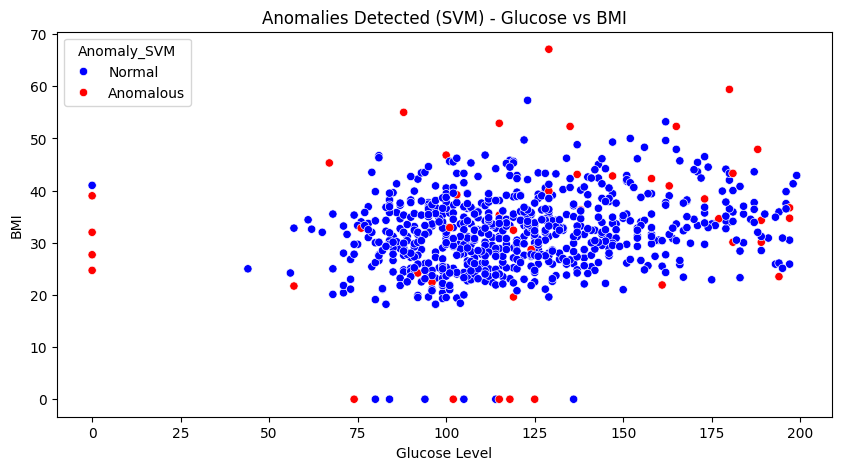

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Load the dataset
df = pd.read_csv("diabetes.csv")

# Display first few rows
print("Dataset preview:")
print(df.head())

# Check for missing values
print("\nMissing values in dataset:\n", df.isnull().sum())

# Normalize numerical features (excluding Outcome column)
scaler = StandardScaler()
X = df.drop(columns=['Outcome'])  # Remove target column for anomaly detection
X_scaled = scaler.fit_transform(X)

# Apply One-Class SVM for anomaly detection
svm = OneClassSVM(kernel="rbf", gamma=0.1, nu=0.05)  # nu defines the proportion of anomalies
df["Anomaly_SVM"] = svm.fit_predict(X_scaled)

# Apply Local Outlier Factor (LOF) for anomaly detection
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% anomalies
df["Anomaly_LOF"] = lof.fit_predict(X_scaled)

# Convert anomaly labels (-1: Anomaly, 1: Normal) to human-readable format
df["Anomaly_SVM"] = df["Anomaly_SVM"].apply(lambda x: "Anomalous" if x == -1 else "Normal")
df["Anomaly_LOF"] = df["Anomaly_LOF"].apply(lambda x: "Anomalous" if x == -1 else "Normal")

# Count detected anomalies
print("\nAnomalies detected by SVM:\n", df["Anomaly_SVM"].value_counts())
print("\nAnomalies detected by LOF:\n", df["Anomaly_LOF"].value_counts())

# Save results for Power BI analysis
df.to_csv("diabetes_anomaly_results.csv", index=False)


# Plot anomalies (Glucose vs. BMI)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Glucose"], y=df["BMI"], hue=df["Anomaly_SVM"], palette={"Anomalous": "red", "Normal": "blue"})
plt.title("Anomalies Detected (SVM) - Glucose vs BMI")
plt.xlabel("Glucose Level")
plt.ylabel("BMI")
plt.show()
